<a href="https://colab.research.google.com/github/SUPRAJ29DB/machine_learning_01/blob/main/knnpractice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
from google.colab import files
file1=files.upload()

Saving large_classification_dataset.csv to large_classification_dataset.csv


In [4]:
import io
filenmae=next(iter(file1))
df=pd.read_csv(io.BytesIO(file1[filenmae]))

In [5]:
df.head()

,Student_ID,Hours_Studied,Attendance,Assignment_Score,Previous_Result,Final_Result
0,72230,6,99,85,Pass,Pass
1,53592,5,87,68,Fail,Pass
2,21912,9,79,65,Fail,Pass
3,76933,8,41,52,Fail,Pass
4,13964,1,80,56,Fail,Fail


In [6]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Previous_Result'] = le.fit_transform(df['Previous_Result'])

df['Final_Result'] = le.fit_transform(df['Final_Result'])

In [7]:
df.drop('Student_ID', axis=1, inplace=True)

In [9]:
df.head()

,Hours_Studied,Attendance,Assignment_Score,Previous_Result,Final_Result
0,6,99,85,1,1
1,5,87,68,0,1
2,9,79,65,0,1
3,8,41,52,0,1
4,1,80,56,0,0


In [11]:
x= df.drop(['Final_Result'], axis=1)
y = df['Final_Result']

In [12]:
x

,Hours_Studied,Attendance,Assignment_Score,Previous_Result
0,6,99,85,1
1,5,87,68,0
2,9,79,65,0
3,8,41,52,0
4,1,80,56,0
...,...,...,...,...
9995,7,45,64,0
9996,3,86,42,0
9997,4,69,73,0
9998,6,78,39,0


In [13]:
y

,Final_Result
0,1
1,1
2,1
3,1
4,0
...,...
9995,1
9996,1
9997,1
9998,1


In [15]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

In [16]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

In [18]:
from sklearn.neighbors import KNeighborsClassifier
classifier = KNeighborsClassifier(n_neighbors=5)
classifier.fit(x_train, y_train)

KNeighborsClassifier()

In [19]:
ypred=classifier.predict(x_test)

In [20]:
from sklearn.metrics import confusion_matrix, accuracy_score

y_pred_train = classifier.predict(x_train)

# Accuracy on training data
accuracy_train = accuracy_score(y_train, y_pred_train)
print(f'Accuracy on training data: {accuracy_train:.2f}')

# Accuracy on test data
accuracy_test = accuracy_score(y_test, ypred)
print(f'Accuracy on test data: {accuracy_test:.2f}')

Accuracy on training data: 1.00
Accuracy on test data: 0.99


### Confusion Matrix Visualization

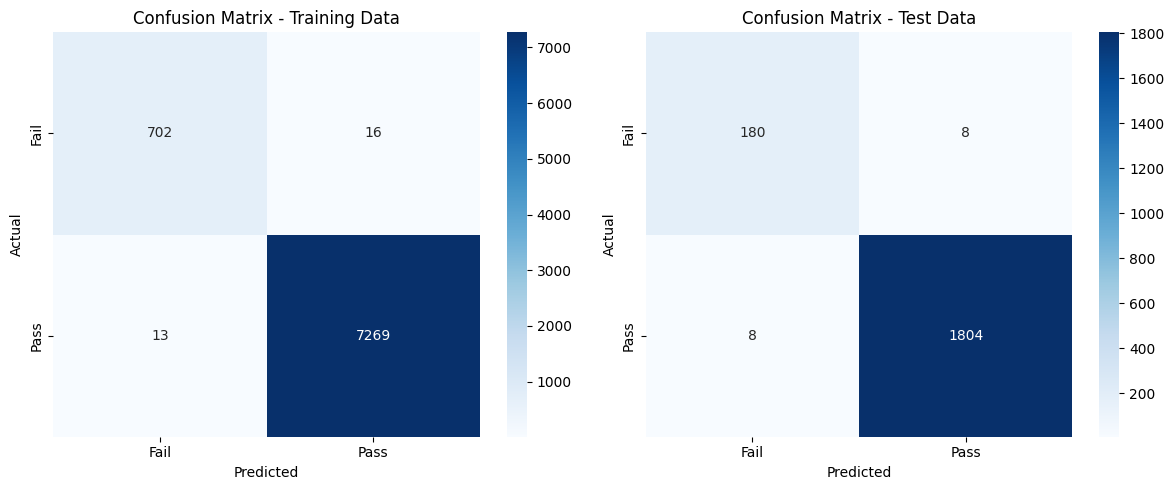

In [21]:
cm_train = confusion_matrix(y_train, y_pred_train)
cm_test = confusion_matrix(y_test, ypred)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Confusion Matrix for Training Data
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=le.classes_, yticklabels=le.classes_)
axes[0].set_title('Confusion Matrix - Training Data')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Confusion Matrix for Test Data
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=le.classes_, yticklabels=le.classes_)
axes[1].set_title('Confusion Matrix - Test Data')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

### Scatter Plot: Hours Studied vs. Assignment Score by Final Result

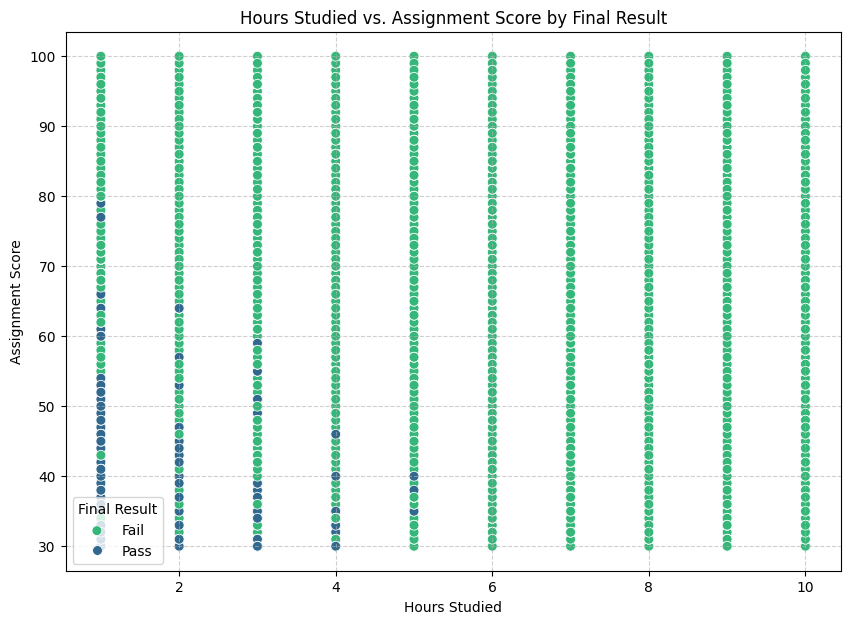

In [22]:
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x='Hours_Studied', y='Assignment_Score', hue='Final_Result', palette='viridis', s=50)
plt.title('Hours Studied vs. Assignment Score by Final Result')
plt.xlabel('Hours Studied')
plt.ylabel('Assignment Score')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Final Result', labels=['Fail', 'Pass'])
plt.show()